# Testing the draft density curve (`new_graphics/density.py`)

This notebook exercises `make_density()`, the draft implementation of the new 1D
density plot type. It is **not** wired into `.plot()` yet — this is for visually
checking the draft before integration.

**How to run:** open this notebook using the `symbulate` conda environment, then Run
All. The setup cell locates the repo root itself (by walking up from the working
directory) so it works regardless of where Jupyter's cwd lands.

**What to look for in every plot:**
- A single smooth line, no fill, in the next Okabe-Ito color
- Light horizontal reference grid, drawn *behind* the curve
- Top and right spines removed
- x-axis reads "Value", y-axis reads "Density", baseline pinned at 0
- x-axis range is quantile-based (0.1st–99.9th percentile + padding), not raw
  min/max, so a heavy-tailed distribution doesn't stretch the axis

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Locate the repo root (the folder containing symbulate/symbulate.mplstyle) by
# walking up from the working directory, so this notebook runs the same way
# regardless of where Jupyter's cwd lands.
_here = Path.cwd()
REPO_ROOT = next(
    p for p in [_here, *_here.parents]
    if (p / "symbulate" / "symbulate.mplstyle").exists()
)
sys.path.insert(0, str(REPO_ROOT / "team" / "new_graphics"))

# The draft helper and its per-plot-type constants
from density import make_density, DENSITY_ALPHA, DENSITY_LINEWIDTH, DENSITY_GRID_POINTS

# Apply the global style file (Okabe-Ito cycle, grid, spines, fonts).
# Not yet wired into the package, so we apply it by hand here.
STYLE_PATH = REPO_ROOT / "symbulate" / "symbulate.mplstyle"
plt.style.use(STYLE_PATH)

rng = np.random.default_rng(7)
print(f"DENSITY_ALPHA = {DENSITY_ALPHA}, DENSITY_LINEWIDTH = {DENSITY_LINEWIDTH}, DENSITY_GRID_POINTS = {DENSITY_GRID_POINTS}")

DENSITY_ALPHA = 1.0, DENSITY_LINEWIDTH = 1.8, DENSITY_GRID_POINTS = 1000


## 1. Reproduce the approved prototype

This should match the prototype image: a sky-blue bell curve for Normal(0, 1),
peaking near 0.40 at x=0, x-axis roughly -4 to 4.

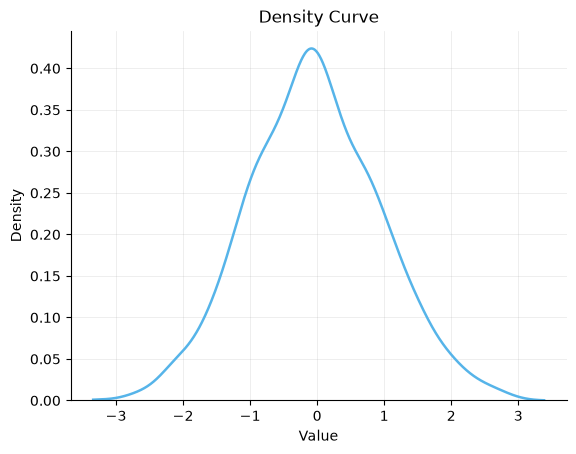

In [2]:
values = rng.normal(0, 1, 2000)

ax = plt.gca()
make_density(values, ax, "#56B4E9")  # Okabe-Ito sky blue, as in the prototype
plt.show()

## 2. Options: bandwidth and alpha overrides

`bandwidth=` is passed through to `scipy.stats.gaussian_kde` as `bw_method`.
A smaller bandwidth should track the data more closely (less smoothing);
a larger one should smooth more aggressively.

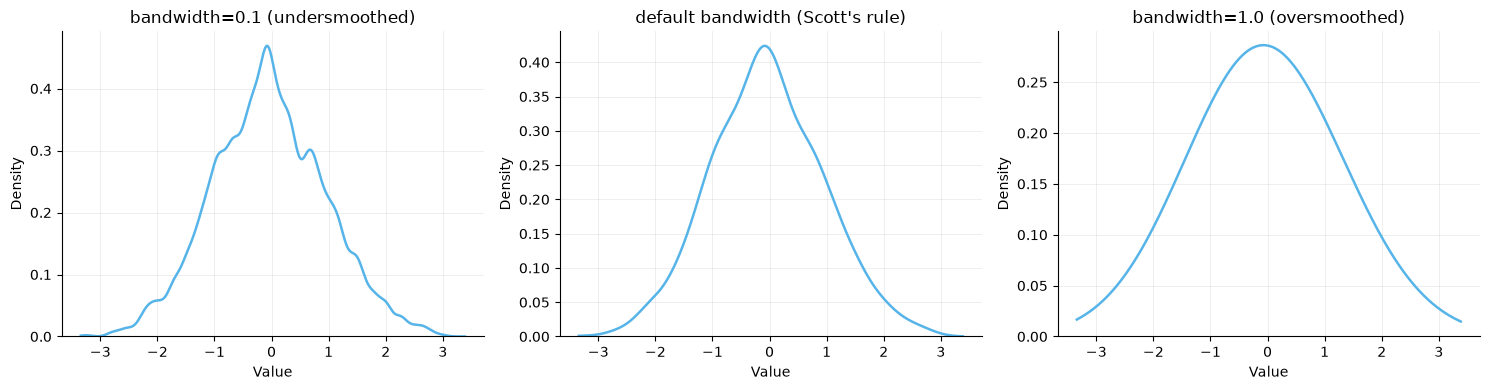

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

make_density(values, axes[0], "#56B4E9", bandwidth=0.1)
axes[0].set_title("bandwidth=0.1 (undersmoothed)")

make_density(values, axes[1], "#56B4E9")
axes[1].set_title("default bandwidth (Scott's rule)")

make_density(values, axes[2], "#56B4E9", bandwidth=1.0)
axes[2].set_title("bandwidth=1.0 (oversmoothed)")

plt.tight_layout()
plt.show()

## 3. Reasonable x-axis limits on a heavy-tailed distribution

This is the case called out explicitly when this plot type was requested: a
distribution like Exponential has unbounded support, so simulated draws will
always include some large outliers. Evaluating the KDE over raw `min()`/`max()`
(as the current inline density code in `results.py` does) stretches the axis
to fit the single largest draw and squashes the real curve into a sliver.
`make_density` instead evaluates over the 0.1st–99.9th percentile plus padding.

The printed comparison below shows how much narrower — and more readable —
the quantile-based range is.

raw min/max range:      [0.00, 9.31]  (width 9.31)
quantile-based x-range:  [-1.07, 7.76]  (width 8.83)


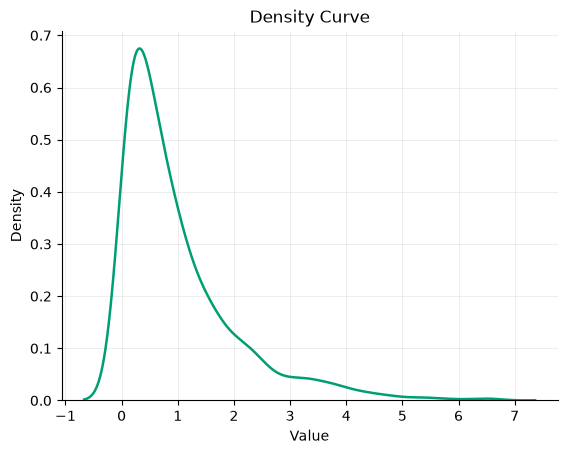

In [4]:
exp_values = rng.exponential(1, 2000)

raw_min, raw_max = exp_values.min(), exp_values.max()
print(f"raw min/max range:      [{raw_min:.2f}, {raw_max:.2f}]  (width {raw_max - raw_min:.2f})")

ax = plt.gca()
make_density(exp_values, ax, "#009E73")
qmin, qmax = ax.get_xlim()
print(f"quantile-based x-range:  [{qmin:.2f}, {qmax:.2f}]  (width {qmax - qmin:.2f})")
plt.show()

## 4. Overlay behavior — mimicking two `.plot()` calls

In the final integration, each `.plot()` call takes its color from
`get_next_color(ax)`. Two overlaid density curves should come out in distinct
Okabe-Ito hues, with a legend appearing automatically once there are two or more.

(Importing `symbulate` currently switches the matplotlib style back to the old
seaborn/ggplot stylesheet — a Phase 2 item — so we re-apply ours right after.)

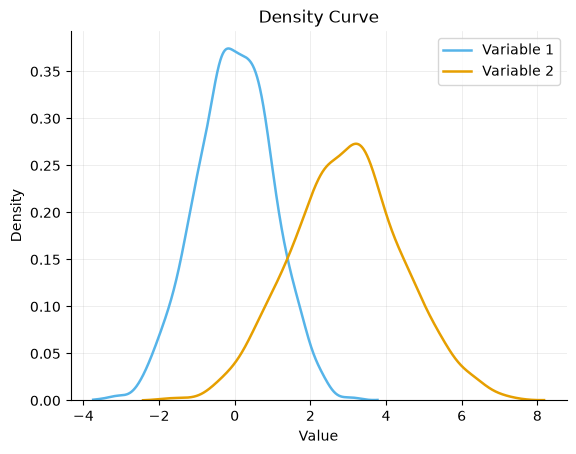

In [5]:
from symbulate.plot import get_next_color

plt.style.use(STYLE_PATH)  # re-apply: importing symbulate overrides the style

sample_a = rng.normal(0, 1, 1500)
sample_b = rng.normal(3, 1.5, 1500)

ax = plt.gca()
make_density(sample_a, ax, get_next_color(ax))
make_density(sample_b, ax, get_next_color(ax))
plt.show()

## 5. With real symbulate simulation data

Same prototype, but the data comes from an actual `RV(...).sim(...)` call instead
of raw numpy.

Caveat while testing today: creating `RVResults` currently calls `init_color()`,
which resets the color cycle to tab10 (removed in Phase 2), so we re-apply the
style *after* simulating.

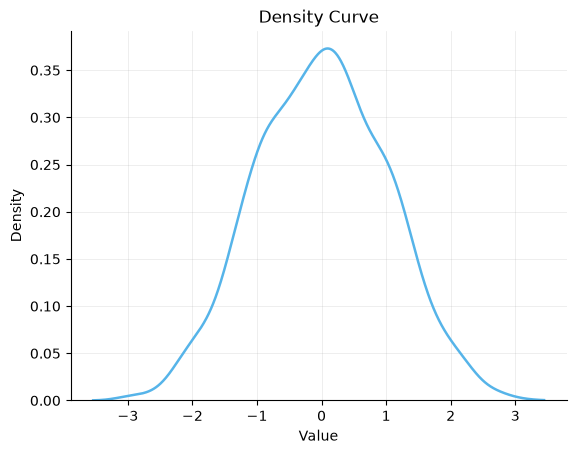

In [6]:
from symbulate import RV, Normal

sims = RV(Normal(0, 1)).sim(2000)

plt.style.use(STYLE_PATH)  # re-apply: RVResults resets the color cycle to tab10

ax = plt.gca()
make_density(np.asarray(sims.results), ax, "#56B4E9")
plt.show()

## 6. The classic teaching use case: true pdf over the simulated KDE curve

`Normal(0, 1).plot()` draws on the same axes via `plt.gca()`, so the true pdf
should overlay the KDE-estimated density almost exactly at n=2000 — a good
visual sanity check that the density estimate is unbiased.

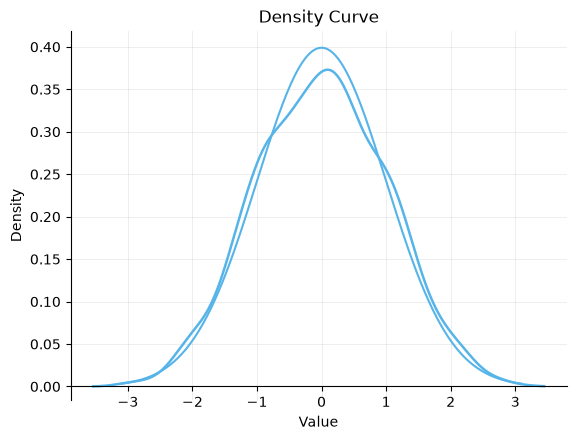

In [7]:
ax = plt.gca()
make_density(np.asarray(sims.results), ax, "#56B4E9", label="Simulated (KDE)")
Normal(0, 1).plot()  # true pdf, drawn on the same axes
plt.show()

## 7. How the x-axis adapts to different distribution shapes

Six differently-shaped distributions, each simulated with `RV(...).sim(2000)`
(the bimodal mixture is built directly from two Normals -- it isn't a single
symbulate distribution), drawn side by side so the quantile-based x-range
adaptation is visible across shapes, not just on one example:

- **Normal(0, 1)** -- symmetric, moderate tails
- **Exponential(1)** -- right-skewed, unbounded right tail
- **Beta(5, 1.5)** -- left-skewed, hard-bounded on [0, 1]
- **Uniform(0, 1)** -- flat, hard-bounded on [0, 1], no real tails at all
- **Bimodal mixture** -- two Normals combined, to check the curve (and axis)
  handle more than one peak
- **Cauchy()** -- extremely heavy-tailed; a handful of simulated draws can land
  hundreds of units out, the most extreme stress test for quantile clipping

Each subplot title prints the raw min/max width next to the actual quantile-based
width `make_density` used, so the adaptation shows up in the numbers as well as
the shape.

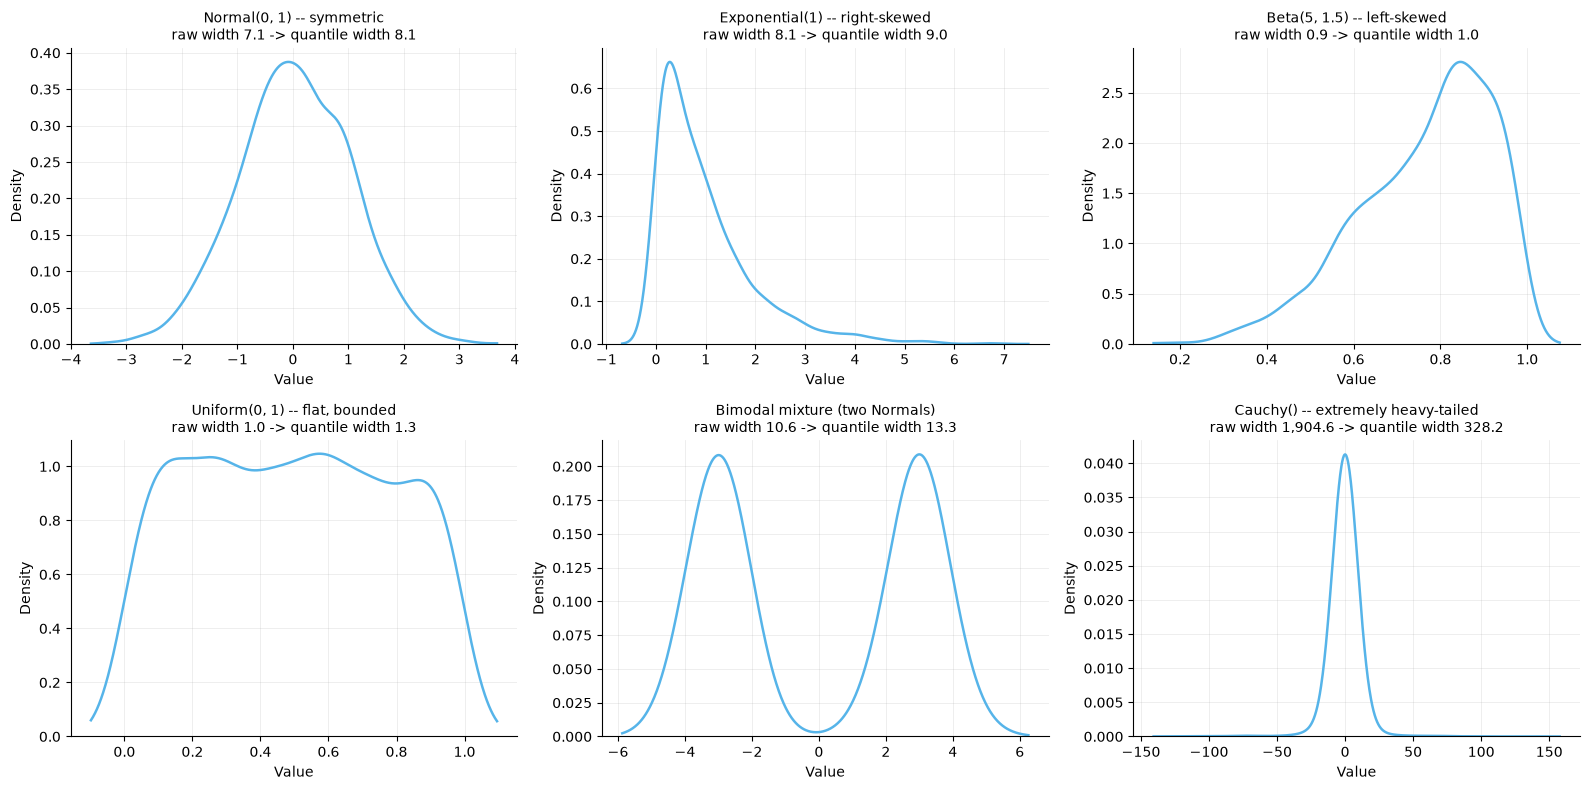

In [8]:
from symbulate import RV, Normal, Exponential, Beta, Uniform, Cauchy

plt.style.use(STYLE_PATH)  # re-apply: RV(...).sim() resets the color cycle to tab10

shapes = [
    ("Normal(0, 1) -- symmetric", np.asarray(RV(Normal(0, 1)).sim(2000).results)),
    ("Exponential(1) -- right-skewed", np.asarray(RV(Exponential(1)).sim(2000).results)),
    ("Beta(5, 1.5) -- left-skewed", np.asarray(RV(Beta(5, 1.5)).sim(2000).results)),
    ("Uniform(0, 1) -- flat, bounded", np.asarray(RV(Uniform(0, 1)).sim(2000).results)),
    (
        "Bimodal mixture (two Normals)",
        np.concatenate([rng.normal(-3, 0.7, 1000), rng.normal(3, 0.7, 1000)]),
    ),
    ("Cauchy() -- extremely heavy-tailed", np.asarray(RV(Cauchy()).sim(2000).results)),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (name, data) in zip(axes.flat, shapes):
    raw_width = data.max() - data.min()
    make_density(data, ax, "#56B4E9")
    qmin, qmax = ax.get_xlim()
    q_width = qmax - qmin
    title = name + chr(10) + f"raw width {raw_width:,.1f} -> quantile width {q_width:,.1f}"
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.show()

## Verification checklist

- [ ] Section 1 matches the approved prototype image
- [ ] Curve is a single smooth line, no fill
- [ ] Horizontal grid behind the curve; no top/right spines; baseline at 0
- [ ] `bandwidth=` override changes smoothing as expected
- [ ] Quantile-based x-range is visibly narrower than raw min/max on Exponential data
- [ ] Overlaid curves get distinct Okabe-Ito colors and a legend at 2+
- [ ] Works on real `.sim()` output, not just numpy arrays
- [ ] True pdf curve overlays cleanly on the simulated density curve
- [ ] Section 7's six subplots each show a sensibly adapted x-range for their shape
